In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from xgboost import XGBRegressor

In [15]:
df = pd.read_csv("DATA/demand_forecasting.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

In [16]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday
df['Weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

In [17]:
df['lag_1_demand'] = df['Demand'].shift(1)
df['lag_7_demand'] = df['Demand'].shift(7)
df['lag_14_demand'] = df['Demand'].shift(14)
df['lag_30_demand'] = df['Demand'].shift(30)

In [18]:
df['Rolling_Mean_7'] = df['Demand'].rolling(window=7).mean()
df['Rolling_Mean_14'] = df['Demand'].rolling(window=14).mean()
df['Rolling_Mean_30'] = df['Demand'].rolling(window=30).mean()

In [19]:
df = df.dropna()

In [20]:
le = LabelEncoder()

df['Region'] = le.fit_transform(df['Region'])
df['Seasonality'] = le.fit_transform(df['Seasonality'])
df['Category'] = le.fit_transform(df['Category'])
df['Promotion'] = le.fit_transform(df['Promotion'])
df['Store ID'] = le.fit_transform(df['Store ID'])
df['Product ID'] = le.fit_transform(df['Product ID'])

# One Hot Encoding Weather
df = pd.get_dummies(df, columns=['Weather Condition'], drop_first=True)

In [21]:
# Drop unnecessary columns
cols_to_drop = ['Date', 'Units Sold', 'Units Ordered', 'Demand']

X = df.drop(columns=cols_to_drop)
y = np.log1p(df['Demand'])   # Log transform target

In [22]:
split_index = int(len(X) * 0.75)

x_train = X.iloc[:split_index]
x_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [23]:
scaler = StandardScaler()

x_train_scale = scaler.fit_transform(x_train)
x_test_scale  = scaler.transform(x_test)

In [24]:
models = {
    "Linear": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Elastic": ElasticNet()
}

for name, model in models.items():
    model.fit(x_train_scale, y_train)
    y_pred = model.predict(x_test_scale)

    print("\n", name)
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


 Linear
R2: 0.34766291502478985
MAE: 0.31171177039955233
RMSE: 0.4165398949583842

 Lasso
R2: -8.78410871960611e-05
MAE: 0.3878016281962704
RMSE: 0.515750481956805

 Ridge
R2: 0.34766333245488457
MAE: 0.31171153169495286
RMSE: 0.4165397616865531

 Elastic
R2: -8.78410871960611e-05
MAE: 0.3878016281962704
RMSE: 0.515750481956805


In [25]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.6503418170936577
MAE: 0.21489680193352675
RMSE: 0.3049596756333332


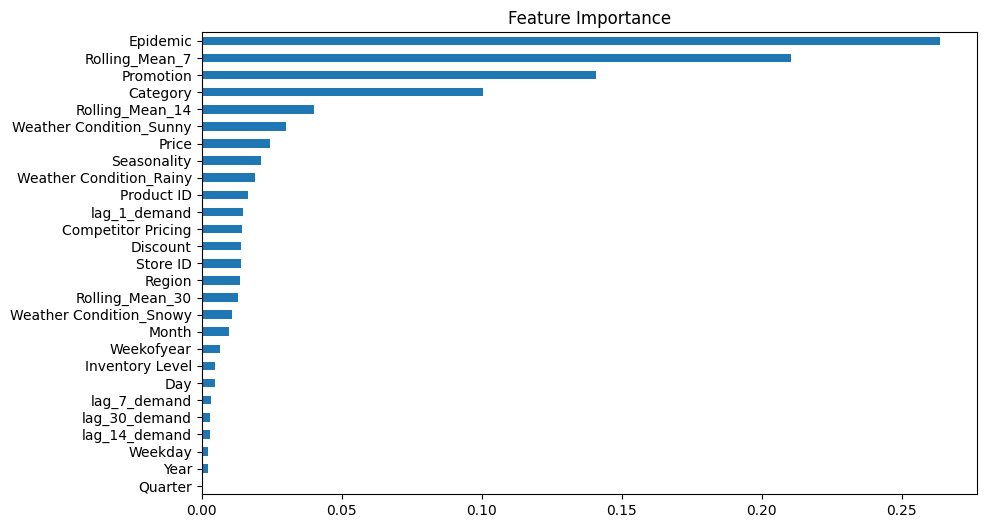

In [26]:
importance = model.feature_importances_
features = x_train.columns

feat_imp = pd.Series(importance, index=features)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(10,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [27]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators':[200,300],
    'max_depth':[4,5,6],
    'learning_rate':[0.03,0.05],
    'subsample':[0.8,1],
    'colsample_bytree':[0.8,1]
}

grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train, y_train)

best_model = grid.best_estimator_

In [28]:
y_train_pred = best_model.predict(x_train)
y_test_pred  = best_model.predict(x_test)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Train R2: 0.7730210864715339
Test R2: 0.7086268914045023


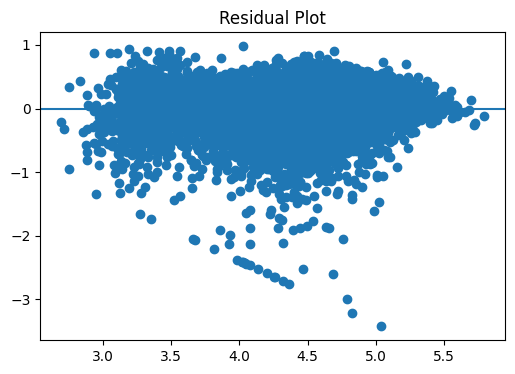

In [29]:
residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.show()

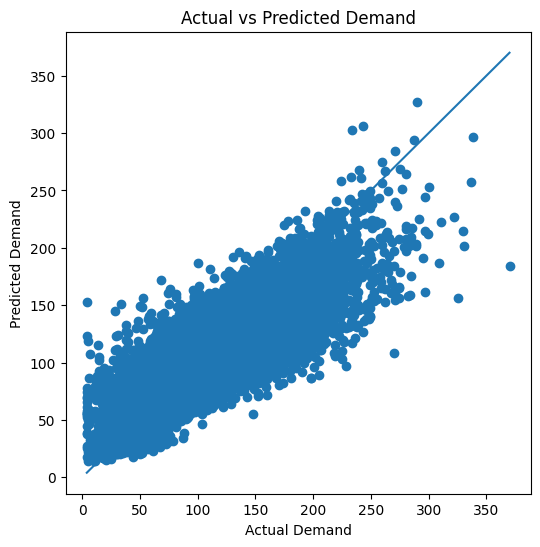

In [30]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_test_pred)

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_actual)

plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()])

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")
plt.show()

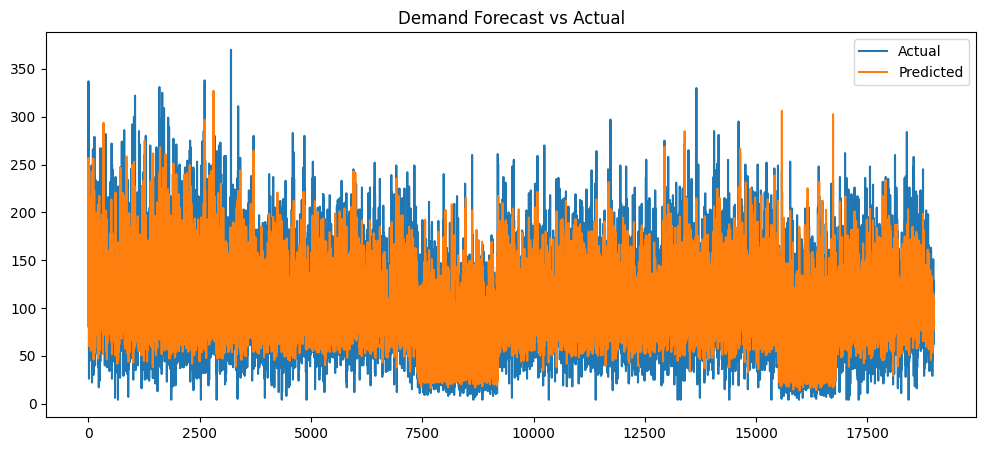

In [31]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual.values, label="Actual")
plt.plot(y_pred_actual, label="Predicted")
plt.legend()
plt.title("Demand Forecast vs Actual")
plt.show()

In [33]:
# modell serialization(model ko memory se file me save kr na)
# joblib is better for sklearn/xgboost models
import joblib
# save model
joblib.dump(best_model,"demand_model.pkl")
# save scaler
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']